In [3]:
# === IMPORTS ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50
from PIL import Image
import os
import random
import numpy as np
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
# === SIAMESE NETWORK WITH RESNET BACKBONE ===
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        base_model = resnet50(pretrained=True)
        for param in base_model.parameters():
            param.requires_grad = False
        base_model.fc = nn.Sequential(
            nn.Linear(base_model.fc.in_features, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )
        self.cnn = base_model

    def forward_once(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        x = self.cnn(x)
        x = F.normalize(x, p=2, dim=1)
        return x

    def forward(self, x1, x2):
        out1 = self.forward_once(x1)
        out2 = self.forward_once(x2)
        return out1, out2


In [5]:
# === CONTRASTIVE LOSS ===
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        distances = F.pairwise_distance(output1, output2)
        loss = (label) * torch.pow(distances, 2) +                (1 - label) * torch.pow(torch.clamp(self.margin - distances, min=0.0), 2)
        return torch.mean(loss)

In [6]:
# === DATASET FOR IMAGE PAIRS ===
class SiameseDataset(Dataset):
    def __init__(self, image_folder_dataset, transform=None):
        self.image_folder_dataset = image_folder_dataset
        self.transform = transform
        self.classes = list(image_folder_dataset.class_to_idx.keys())
        self.class_to_images = {cls: [] for cls in self.classes}
        for img_path, label in image_folder_dataset.samples:
            cls_name = self.classes[label]
            self.class_to_images[cls_name].append(img_path)

    def __getitem__(self, index):
        cls1 = random.choice(self.classes)
        is_same = random.randint(0, 1)
        img1_path = random.choice(self.class_to_images[cls1])
        img1 = Image.open(img1_path).convert("L")
        if is_same:
            img2_path = random.choice(self.class_to_images[cls1])
        else:
            cls2 = random.choice([c for c in self.classes if c != cls1])
            img2_path = random.choice(self.class_to_images[cls2])
        img2 = Image.open(img2_path).convert("L")
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
        label = torch.tensor(float(is_same), dtype=torch.float32)
        return img1, img2, label

    def __len__(self):
        return sum(len(paths) for paths in self.class_to_images.values())


In [7]:
# === DATA LOADING ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ImageFolder("/kaggle/input/flowers-recognition/flowers")  # replace with your path
siamese_dataset = SiameseDataset(dataset, transform=transform)
train_loader = DataLoader(siamese_dataset, shuffle=True, batch_size=32)


In [8]:
# === TRAINING ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseNetwork().to(device)
criterion = ContrastiveLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 30
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        output1, output2 = model(img1, img2)
        loss = criterion(output1, output2, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s] 


Epoch 1, Loss: 0.1986
Epoch 2, Loss: 0.1671
Epoch 3, Loss: 0.1557
Epoch 4, Loss: 0.1453
Epoch 5, Loss: 0.1416
Epoch 6, Loss: 0.1367
Epoch 7, Loss: 0.1273
Epoch 8, Loss: 0.1235
Epoch 9, Loss: 0.1198
Epoch 10, Loss: 0.1146
Epoch 11, Loss: 0.1139
Epoch 12, Loss: 0.1065
Epoch 13, Loss: 0.1098
Epoch 14, Loss: 0.1027
Epoch 15, Loss: 0.1013
Epoch 16, Loss: 0.0962
Epoch 17, Loss: 0.0938
Epoch 18, Loss: 0.0918
Epoch 19, Loss: 0.0846
Epoch 20, Loss: 0.0876
Epoch 21, Loss: 0.0810
Epoch 22, Loss: 0.0769
Epoch 23, Loss: 0.0742
Epoch 24, Loss: 0.0721
Epoch 25, Loss: 0.0702
Epoch 26, Loss: 0.0624
Epoch 27, Loss: 0.0644
Epoch 28, Loss: 0.0599
Epoch 29, Loss: 0.0588
Epoch 30, Loss: 0.0547


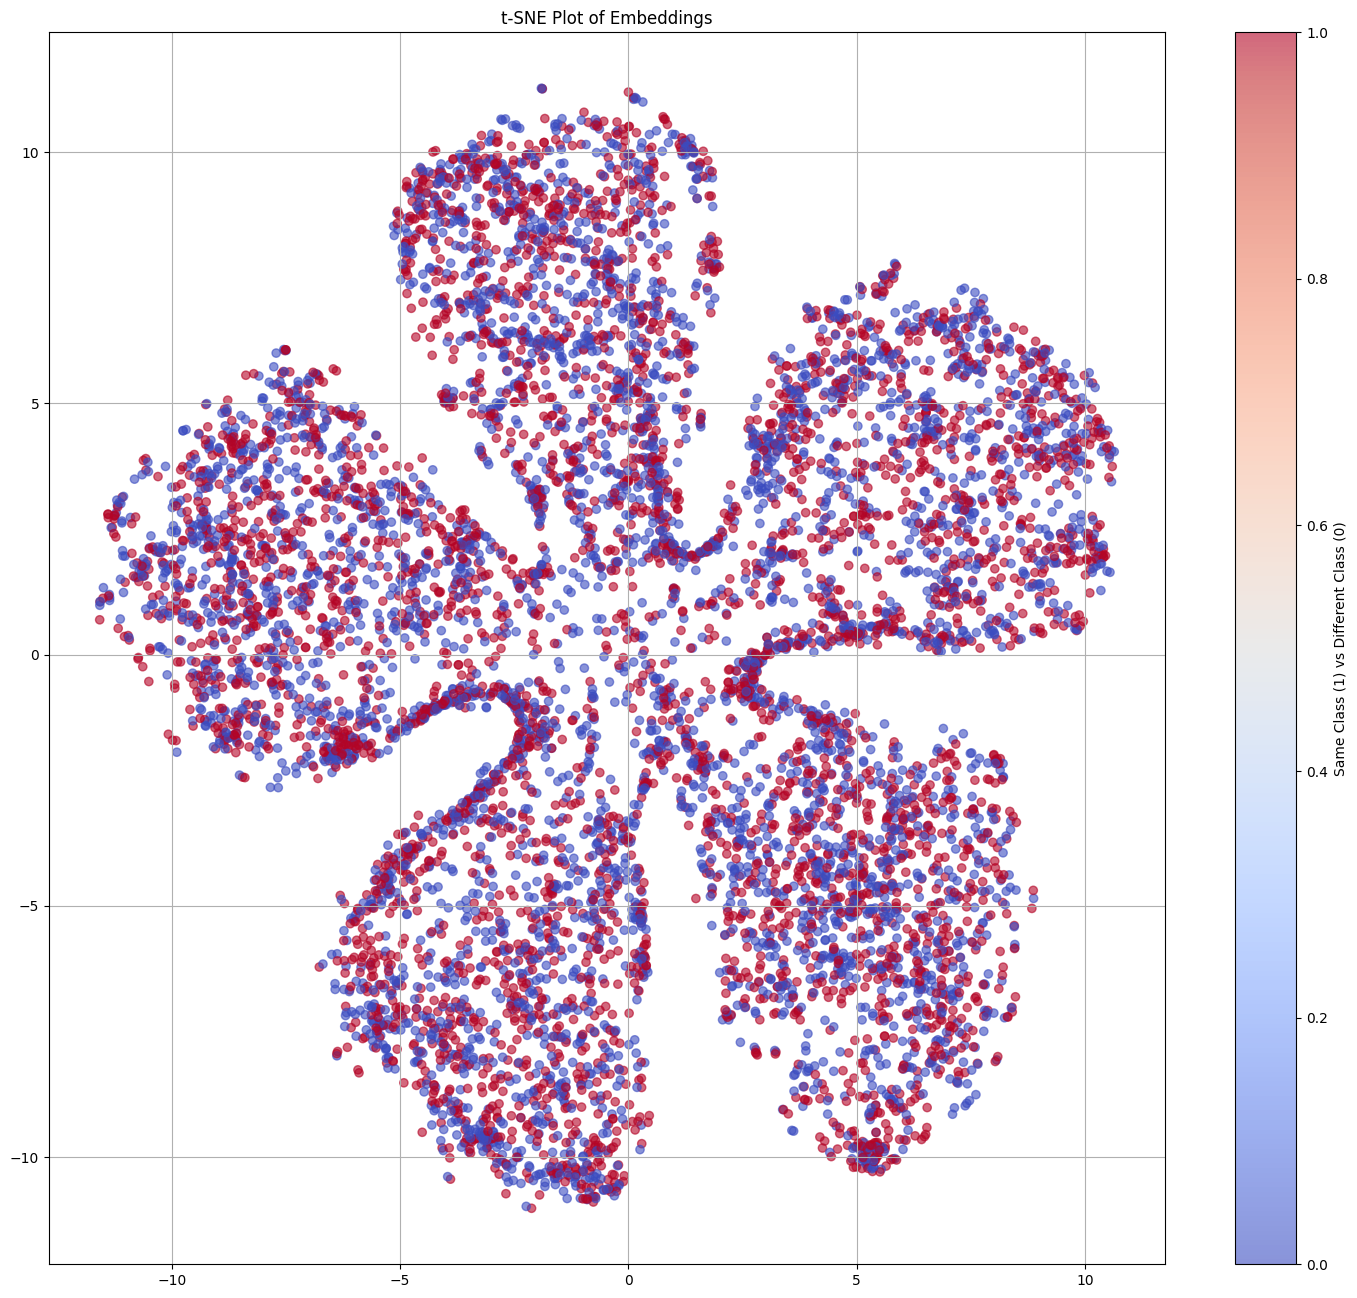

In [9]:
# === TSNE VISUALIZATION ===
from sklearn.manifold import TSNE

# Collect embeddings and labels
embeddings = []
labels = []

with torch.no_grad():
    for img1, img2, label in train_loader:
        img1, img2 = img1.to(device), img2.to(device)
        emb1, emb2 = model(img1, img2)
        embeddings.append(emb1.cpu().numpy())
        embeddings.append(emb2.cpu().numpy())
        labels.extend(label.numpy())
        labels.extend(label.numpy())  # duplicate because we added both emb1 and emb2

embeddings = np.concatenate(embeddings, axis=0)
labels = np.array(labels)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
tsne_result = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(18, 16))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
plt.title("t-SNE Plot of Embeddings")
plt.colorbar(label="Same Class (1) vs Different Class (0)")
plt.grid(True)
plt.show()


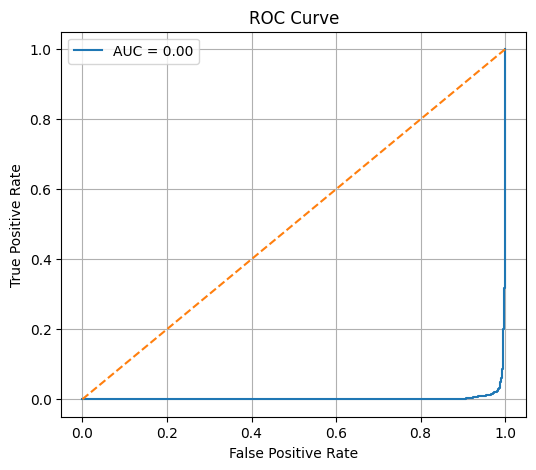

In [10]:
# === EVALUATION ===
model.eval()
y_true = []
y_scores = []
with torch.no_grad():
    for img1, img2, label in train_loader:
        img1, img2 = img1.to(device), img2.to(device)
        output1, output2 = model(img1, img2)
        distances = F.pairwise_distance(output1, output2)
        y_true.extend(label.numpy())
        y_scores.extend(distances.cpu().numpy())

# ROC CURVE
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


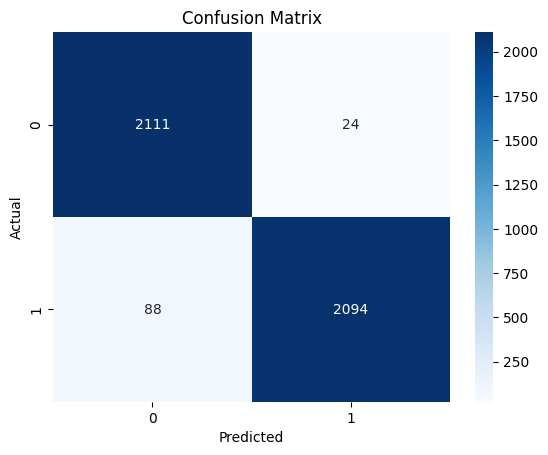

In [11]:
# CONFUSION MATRIX & CLASSIFICATION REPORT
y_pred = [1 if s < 0.5 else 0 for s in y_scores]
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



In [12]:
print("Classification Report:")
print(classification_report(y_true, y_pred, digits=3))

Classification Report:
              precision    recall  f1-score   support

         0.0      0.960     0.989     0.974      2135
         1.0      0.989     0.960     0.974      2182

    accuracy                          0.974      4317
   macro avg      0.974     0.974     0.974      4317
weighted avg      0.974     0.974     0.974      4317

